17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape : (25000, 200)
Testing Shape : (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 171s 535ms/step - accuracy: 0.7806 - loss: 0.4513 - val_accuracy: 0.8390 - val_loss: 0.3676
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 175s 559ms/step - accuracy: 0.8989 - loss: 0.2563 - val_accuracy: 0.8590 - val_loss: 0.3269
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 175s 558ms/step - accuracy: 0.9287 - loss: 0.1904 - val_accuracy: 0.8608 - val_loss: 0.3650
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 166s 530ms/step - accuracy: 0.9481 - loss: 0.1437 - val_accuracy: 0.8592 - val_loss: 0.4061
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 532ms/step - accuracy: 0.9654 - loss: 0.0969 - val_accuracy: 0.8404 - val_loss: 0.5635
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 104ms/step - accuracy: 0.8472 - loss: 0.5478

Test Accuracy : 0.8472399711608887


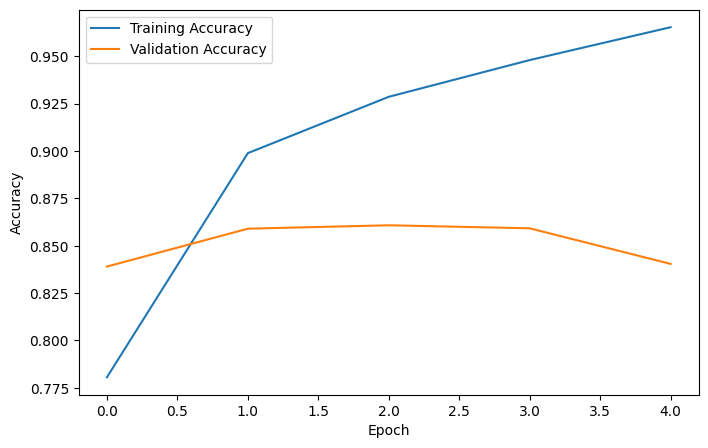

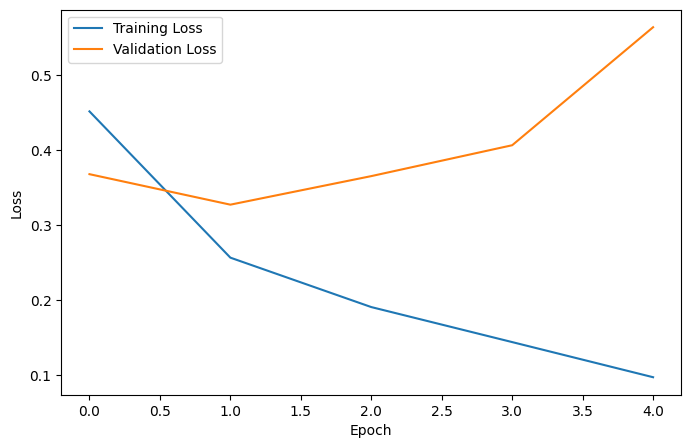

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

# Vocabulary Size
vocab_size = 10000

# Load IMDB Dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# Padding Sequences
max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Build Deep NLP Model
model = Sequential()

# Embedding Layer
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

# LSTM Layer
model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

# Dropout Layer
model.add(Dropout(0.5))

# Dense Layer
model.add(Dense(
    64,
    activation='relu'
))

# Output Layer
model.add(Dense(
    1,
    activation='sigmoid'
))

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Accuracy :", test_accuracy)

# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()